# 01 — Data exploration

Mini-Cheetah contact dataset: 15 recordings at 1 kHz, 54 proprioceptive channels,
4 binary contact labels (`RF, LF, RH, LH`).

Task: from the last 150 timesteps (150 ms), predict which feet are in contact **now**.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_recordings, split, check_no_overlap, LEGS, WINDOW

recs = load_recordings()
sp = split(recs, stride=1)
check_no_overlap(sp)

# channel layout: q 0-11 | qd 12-23 | imu_acc 24-26 | imu_omega 27-29 | p 30-41 | v 42-53
# p and v are foot position/velocity in the body frame, (x, y, z) per leg, legs ordered RF, LF, RH, LH
P_Z = [30 + 3 * k + 2 for k in range(4)]
V_Z = [42 + 3 * k + 2 for k in range(4)]

def body_height(X):            # mean height of the body above the 4 feet [m]
    return -X[:, P_Z].mean(1)

def rolling(a, n=1000):        # centered moving average, no zero-padding at the edges
    return pd.Series(a).rolling(n, center=True, min_periods=1).mean().to_numpy()

## Recordings: length and contact ratio per leg

In [2]:
pd.DataFrame({name: {"seconds": len(X) / 1000, **dict(zip(LEGS, y.mean(0).round(2)))}
              for name, (X, y) in recs.items()}).T

,seconds,RF,LF,RH,LH
air_jumping_gait,48.672,0.00,0.00,0.00,0.00
air_walking_gait,44.086,0.00,0.00,0.00,0.00
asphalt_road,25.885,0.35,0.35,0.35,0.35
old_asphalt_road,68.130,0.34,0.32,0.34,0.35
concrete_difficult_slippery,115.685,0.36,0.35,0.35,0.35
concrete_galloping,49.311,0.46,0.48,0.46,0.43
concrete_left_circle,95.626,0.35,0.36,0.35,0.35
concrete_pronking,102.908,0.54,0.55,0.53,0.53
concrete_right_circle,100.114,0.36,0.35,0.35,0.35
forest,71.844,0.34,0.34,0.34,0.34


The two `air_*` recordings never touch the ground (robot held in the air, legs moving): all labels are 0.
Ground recordings have each foot in contact ~35% of the time (trot); pronking and galloping more.

## Every recording, start to end

Black = fraction of feet in contact (1 s moving average). Grey = body height above the feet.
Background = train / val / test blocks. A stand-up or sit-down phase would show as a change in body height
and contact ratio → 1 (all feet down) at the edges.

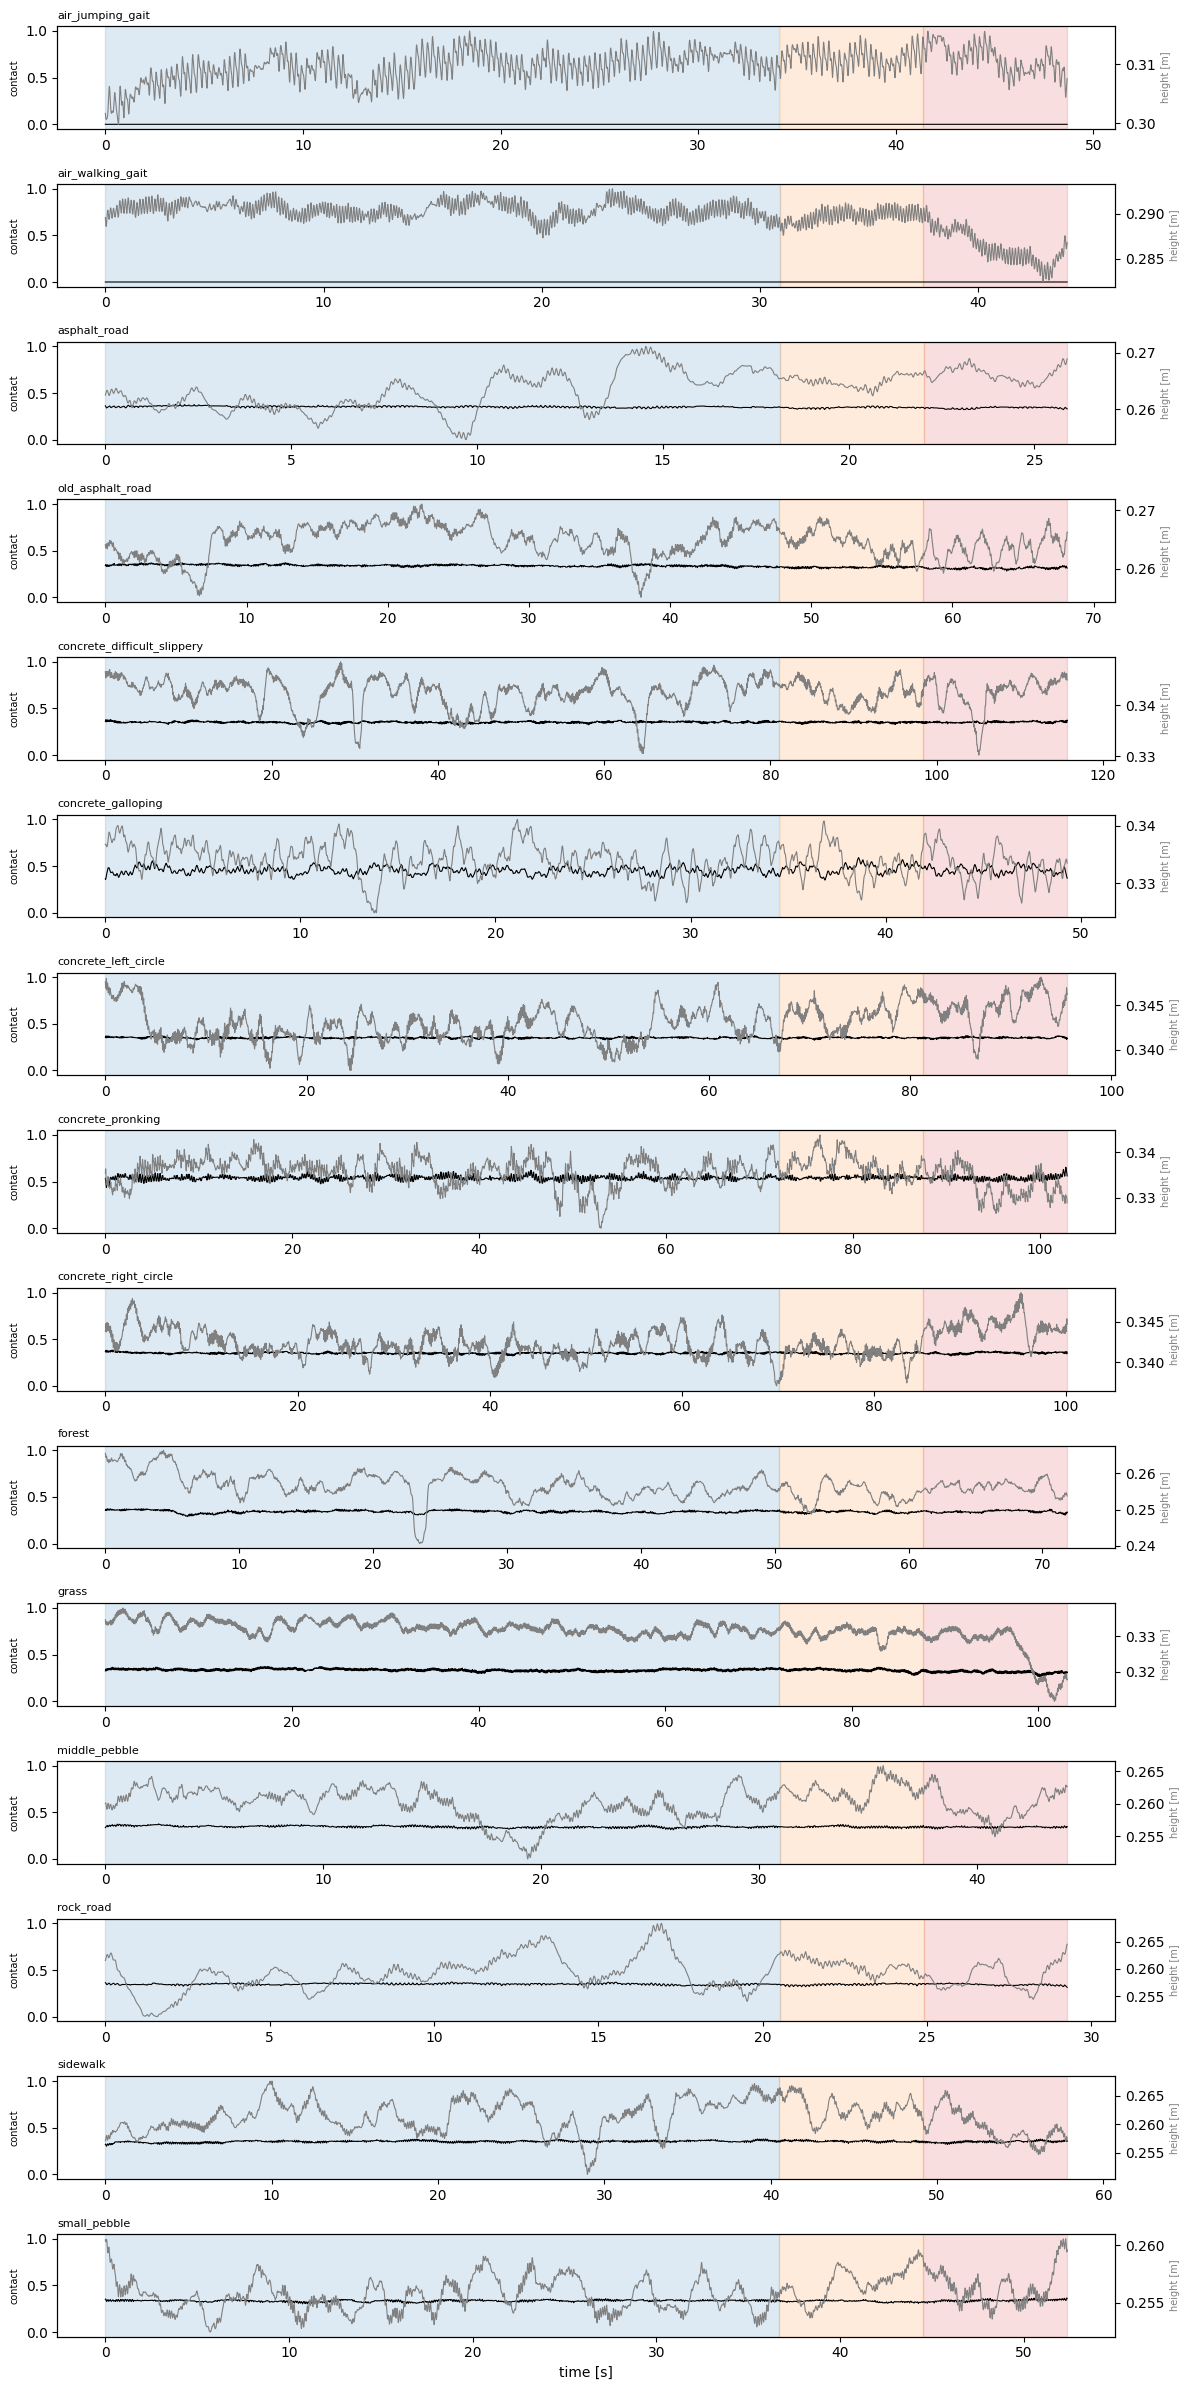

In [3]:
fig, axes = plt.subplots(len(recs), 1, figsize=(12, 1.6 * len(recs)))
for ax, (name, (X, y)) in zip(axes, recs.items()):
    t = np.arange(len(y)) / 1000
    ax.plot(t, rolling(y.mean(1)), color="k", lw=0.8)
    ax.set_ylim(-0.05, 1.05); ax.set_ylabel("contact", fontsize=7)
    ax2 = ax.twinx()
    ax2.plot(t, rolling(body_height(X)), color="grey", lw=0.8)
    ax2.set_ylabel("height [m]", fontsize=7, color="grey")
    for part, color in zip(sp, ["tab:blue", "tab:orange", "tab:red"]):
        e = sp[part][name]
        ax.axvspan((e[0] - WINDOW + 1) / 1000, e[-1] / 1000, alpha=0.15, color=color)
    ax.set_title(name, fontsize=8, loc="left")
axes[-1].set_xlabel("time [s]")
plt.tight_layout()

## Body height per recording

Two groups: the `concrete_*` recordings and `grass` walk at ~0.34 m, all other terrains at ~0.26 m
(~8 cm lower; probably a different session/setup). The air recordings sit in between.
Not a problem for protocol A (every recording is in train), but the same signal (e.g. foot height) has a
different typical range depending on the recording — see the scatter plot below.

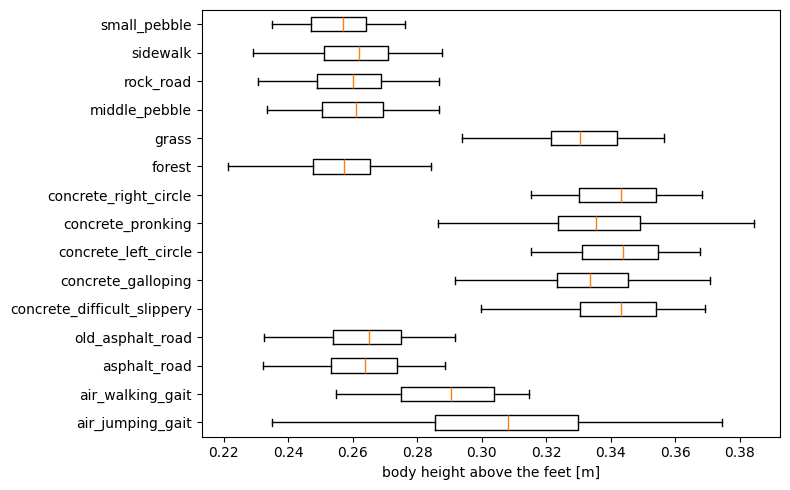

In [4]:
plt.figure(figsize=(8, 5))
plt.boxplot([body_height(X)[::10] for X, _ in recs.values()], vert=False, showfliers=False)
plt.yticks(range(1, len(recs) + 1), list(recs))
plt.xlabel("body height above the feet [m]"); plt.tight_layout()

## Zoom on the first and last 3 seconds

Raw labels, one row per leg (dark = contact). The robot is already walking at the first sample: no stand-up or
sit-down phase. In the raw files the last 100-270 ms of every ground recording had (almost) no contact labels while
the robot was still walking — the labels stop before the sensor data. `load_recordings` drops the last
300 ms (`TRIM_END`), so the end shown here is already trimmed.

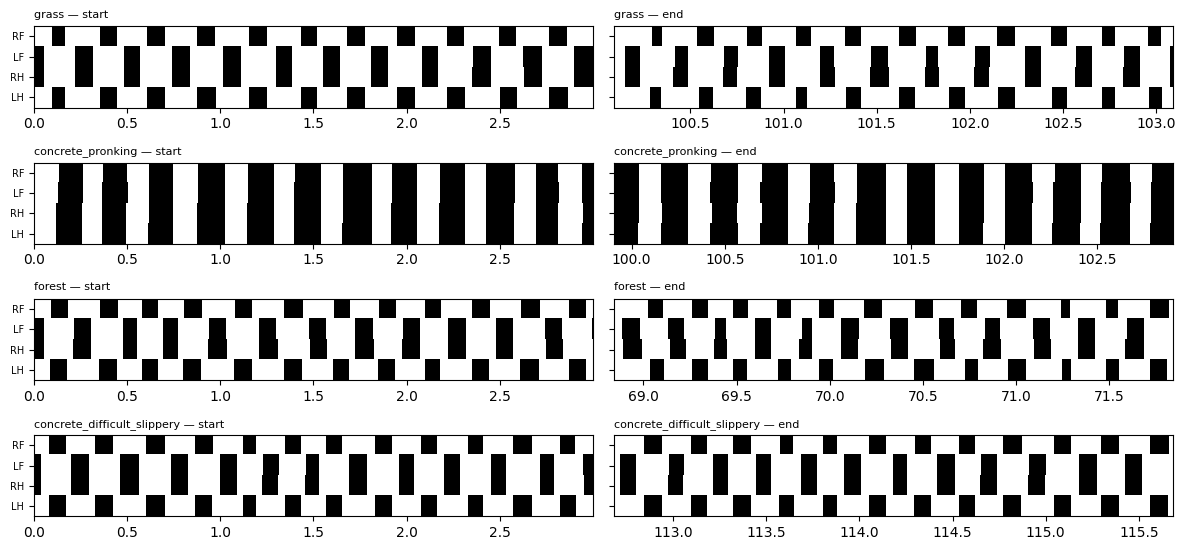

In [5]:
names = ["grass", "concrete_pronking", "forest", "concrete_difficult_slippery"]
fig, axes = plt.subplots(len(names), 2, figsize=(12, 1.4 * len(names)), sharey=True)
for row, name in zip(axes, names):
    X, y = recs[name]
    for ax, sl, label in [(row[0], slice(0, 3000), "start"), (row[1], slice(len(y) - 3000, len(y)), "end")]:
        t = np.arange(len(y))[sl] / 1000
        ax.imshow(y[sl].T, aspect="auto", cmap="Greys", interpolation="nearest",
                  extent=[t[0], t[-1], 3.5, -0.5], vmin=0, vmax=1)
        ax.set_yticks(range(4), LEGS, fontsize=7)
        ax.set_title(f"{name} — {label}", fontsize=8, loc="left")
plt.tight_layout()

## Gaits: 1 s of each recording

Footfall diagram (dark = foot in contact). The red box is one input window (150 ms) — the model sees
the 54 signals inside it and predicts the contact state at its right edge.

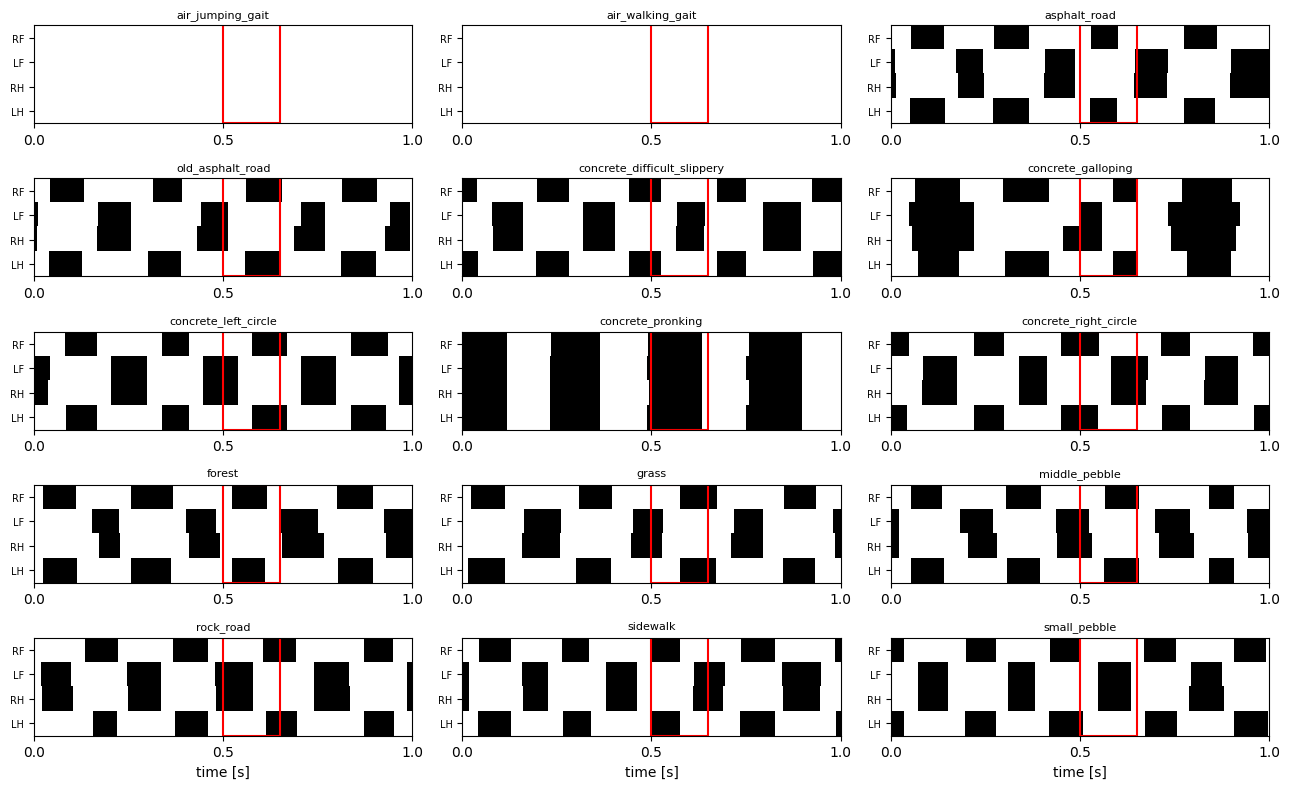

In [6]:
fig, axes = plt.subplots(5, 3, figsize=(13, 8))
for ax, (name, (X, y)) in zip(axes.flat, recs.items()):
    mid = len(y) // 2
    sl = slice(mid, mid + 1000)
    ax.imshow(y[sl].T, aspect="auto", cmap="Greys", interpolation="nearest", extent=[0, 1, 3.5, -0.5], vmin=0, vmax=1)
    ax.add_patch(plt.Rectangle((0.5, -0.5), WINDOW / 1000, 4, fill=False, color="red", lw=1.5))
    ax.set_yticks(range(4), LEGS, fontsize=7); ax.set_xticks([0, 0.5, 1])
    ax.set_title(name, fontsize=8)
for ax in axes[-1]: ax.set_xlabel("time [s]")
plt.tight_layout()

Trot: diagonal pairs (RF+LH, LF+RH) alternate. Pronking: all four feet together. Galloping: front and
hind pairs alternate. One 150 ms window covers roughly half a stride.

## What the signals look like: 1 s of `grass`, right-front foot

Shaded = foot in contact.

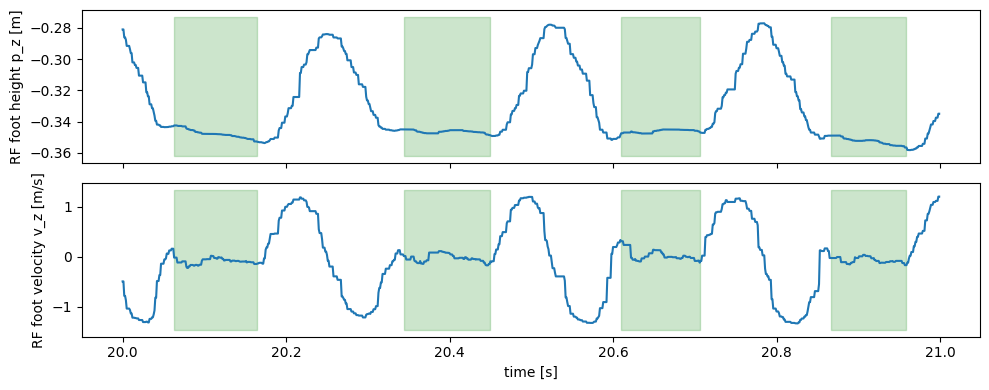

In [7]:
X, y = recs["grass"]
t = np.arange(20_000, 21_000)
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, (ch, label) in zip(axes, [(P_Z[0], "RF foot height p_z [m]"), (V_Z[0], "RF foot velocity v_z [m/s]")]):
    ax.plot(t / 1000, X[t, ch])
    ax.fill_between(t / 1000, *ax.get_ylim(), where=y[t, 0] == 1, alpha=0.2, color="green")
    ax.set_ylabel(label)
axes[-1].set_xlabel("time [s]")
plt.tight_layout()

Foot height is low and velocity is near zero when the foot is in contact.
Velocity is positive *and* negative during swing and near zero in contact — a linear function of `v_z`
cannot express "close to zero" (same issue as the amplitude in the EMG project).

## Is the label linearly separable? Foot height vs foot velocity (RF)

Training blocks only (relationships we model should not be read off the test data).
20k random timesteps, green = in contact.

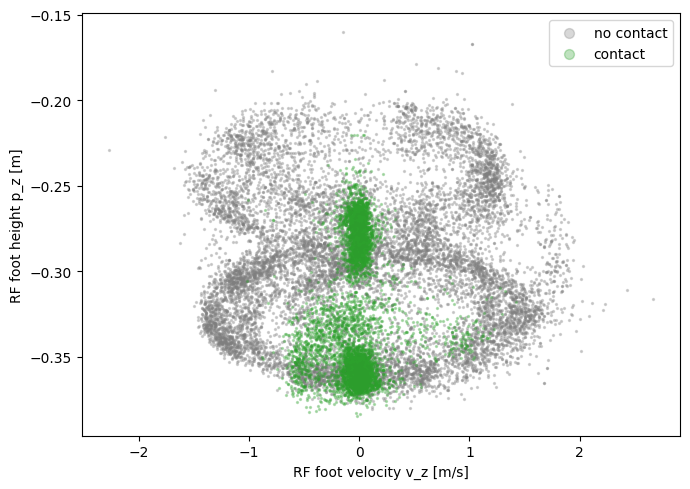

In [8]:
# all training timesteps, right-front leg
tr = np.concatenate([recs[n][0][sp["train"][n]] for n in recs])
ytr = np.concatenate([recs[n][1][sp["train"][n]] for n in recs])
idx = np.random.default_rng(0).choice(len(tr), 20_000, replace=False)
c = ytr[idx, 0] == 1
plt.figure(figsize=(7, 5))
plt.scatter(tr[idx][~c, V_Z[0]], tr[idx][~c, P_Z[0]], s=2, alpha=0.3, color="tab:grey", label="no contact")
plt.scatter(tr[idx][c, V_Z[0]], tr[idx][c, P_Z[0]], s=2, alpha=0.3, color="tab:green", label="contact")
plt.xlabel("RF foot velocity v_z [m/s]"); plt.ylabel("RF foot height p_z [m]")
plt.legend(markerscale=5); plt.tight_layout()

Contact sits in narrow vertical bands around `v_z ≈ 0`, with swing on **both** sides (the swing
trajectories form loops around them): no single straight line separates the classes in this plane.
A linear model needs a feature like `|v_z|` or `v_z²` — or a kernel.

There are **two** contact clusters, at p_z ≈ -0.36 m and ≈ -0.28 m: the two body-height groups above.
The upper one overlaps the swing heights of the lower group, so foot height alone cannot be thresholded
globally — it only means something relative to the recording's body height.

## Single channels: contact vs no contact (RF)

Same training timesteps. Where the two distributions are shifted, a threshold (and a linear model) can use
the channel; where they share the centre but differ in spread, it cannot.

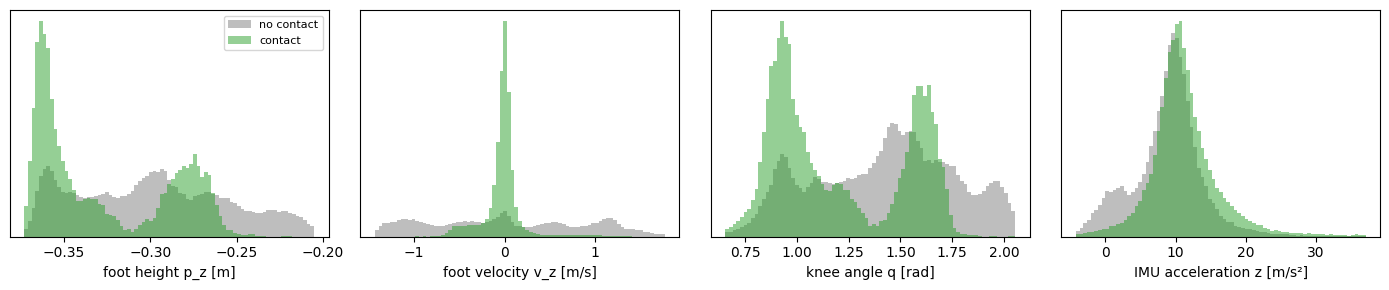

In [9]:
channels = [(P_Z[0], "foot height p_z [m]"), (V_Z[0], "foot velocity v_z [m/s]"),
            (2, "knee angle q [rad]"), (26, "IMU acceleration z [m/s²]")]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (ch, label) in zip(axes, channels):
    lo, hi = np.percentile(tr[:, ch], [0.5, 99.5])
    bins = np.linspace(lo, hi, 80)
    ax.hist(tr[ytr[:, 0] == 0, ch], bins, density=True, alpha=0.5, color="tab:grey", label="no contact")
    ax.hist(tr[ytr[:, 0] == 1, ch], bins, density=True, alpha=0.5, color="tab:green", label="contact")
    ax.set_xlabel(label); ax.set_yticks([])
axes[0].legend(fontsize=8); plt.tight_layout()

- **Foot height**: shifted (contact lower), but bimodal because of the two body heights.
- **Foot velocity**: same centre, very different spread: contact is a spike at 0, swing is spread on both
  sides. Highly informative, but not linearly.
- **Knee angle**: partly shifted, bimodal for the same reason as foot height.
- **IMU acceleration**: the two distributions almost overlap; little information for one leg on its own.

## One input window, all 54 channels

What a single sample looks like for the model, for three gaits. Each channel is min-max scaled over the
recording so they fit one colour scale. Label = contact state at the last column.

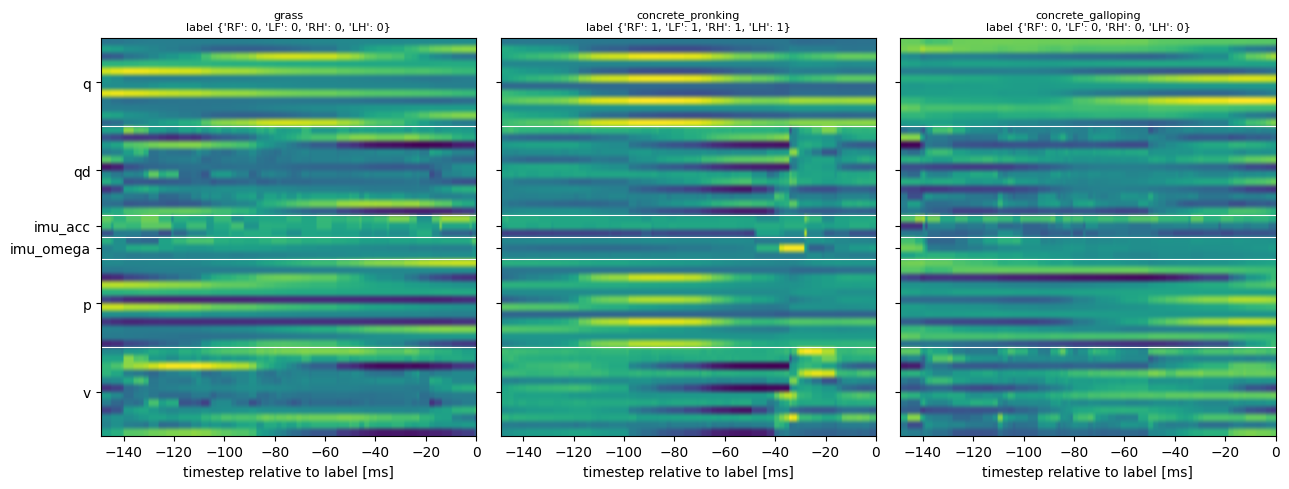

In [10]:
fields = [("q", 12), ("qd", 12), ("imu_acc", 3), ("imu_omega", 3), ("p", 12), ("v", 12)]
edges = np.cumsum([0] + [n for _, n in fields])
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
for ax, name in zip(axes, ["grass", "concrete_pronking", "concrete_galloping"]):
    X, y = recs[name]
    e = len(y) // 2
    lo, hi = X.min(0), X.max(0)
    w = (X[e - WINDOW + 1 : e + 1] - lo) / (hi - lo + 1e-9)
    ax.imshow(w.T, aspect="auto", cmap="viridis", extent=[-WINDOW + 1, 0, 53.5, -0.5])
    ax.hlines(edges[1:-1] - 0.5, -WINDOW + 1, 0, color="w", lw=0.8)
    ax.set_title(f"{name}\nlabel {dict(zip(LEGS, y[e].tolist()))}", fontsize=8)
    ax.set_xlabel("timestep relative to label [ms]")
axes[0].set_yticks((edges[:-1] + edges[1:]) / 2 - 0.5, [f for f, _ in fields])
plt.tight_layout()

## Contact states: how often each of the 16 combinations occurs

We predict each leg as a separate binary problem (contact vs no contact). This plot shows how strongly
the legs are coupled — 4 states cover ~95% of the data (trot pairs `1001`/`0110`, all up, all down) — which is
why each leg's model gets every leg's features as input. It is also the basis of the exact-state accuracy
metric (all 4 legs right at once).

0000    0.367
1001    0.263
0110    0.261
1111    0.061
0010    0.011
0100    0.011
0001    0.009
1000    0.009
Name: proportion, dtype: float64

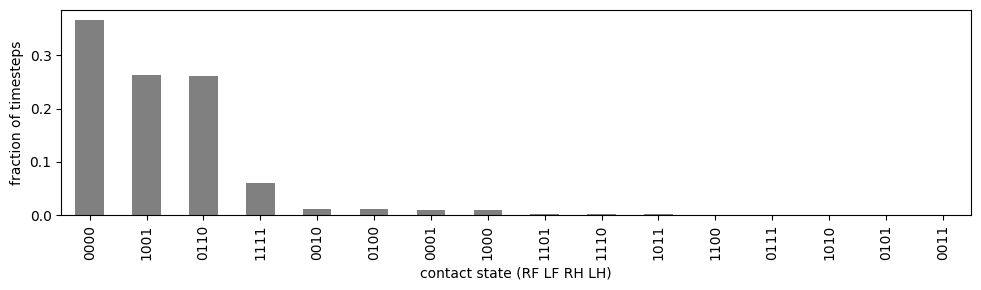

In [11]:
Y = np.concatenate([y for _, y in recs.values()])
states = pd.Series(Y @ [8, 4, 2, 1]).map(lambda s: format(s, "04b"))
counts = states.value_counts(normalize=True)
counts.plot.bar(figsize=(10, 3), color="grey")
plt.ylabel("fraction of timesteps"); plt.xlabel("contact state (RF LF RH LH)")
plt.tight_layout()
counts.round(3).head(8)

## How long does the correlation last? Autocorrelation vs time lag (`grass`, RF)

How similar a signal is to itself shifted by a lag. It oscillates with the gait cycle (period ≈ 265 ms)
and decays only slowly: samples 150 ms apart (non-overlapping windows) are strongly *anti*-correlated
(≈ -0.5), and three strides later (≈ 800 ms) the correlation is still ≈ 0.8. This is why the split uses contiguous blocks, and why the number of
windows overstates the number of independent samples.

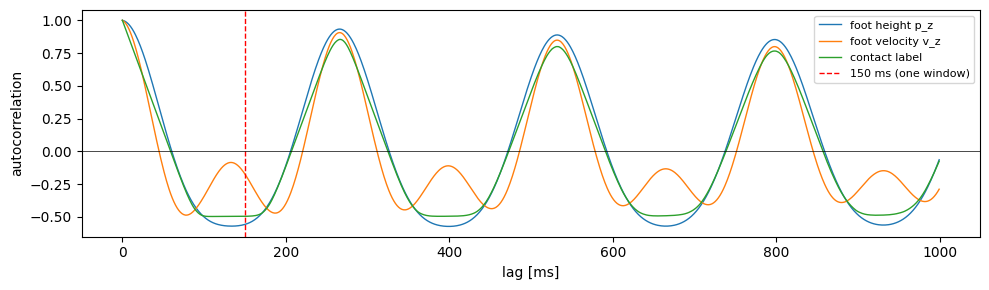

In [12]:
def autocorr(a, max_lag):
    a = a - a.mean()
    f = np.fft.rfft(a, 2 * len(a))
    r = np.fft.irfft(f * np.conj(f))[:max_lag]
    return r / r[0]

X, y = recs["grass"]
lags = np.arange(1000)
plt.figure(figsize=(10, 3))
for sig, label in [(X[:, P_Z[0]], "foot height p_z"), (X[:, V_Z[0]], "foot velocity v_z"), (y[:, 0], "contact label")]:
    plt.plot(lags, autocorr(sig.astype(float), 1000), label=label, lw=1)
plt.axvline(WINDOW, color="red", ls="--", lw=1, label="150 ms (one window)")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("lag [ms]"); plt.ylabel("autocorrelation"); plt.legend(fontsize=8); plt.tight_layout()

## Split (protocol A)

Each recording is cut in time: `[ train 70% | gap | val 15% | gap | test 15% ]`.
Gaps are 150 steps (one window), so no timestep appears in two sets.
Contact ratio per set — are val/test similar to train?

In [13]:
pd.DataFrame({name: {part: recs[name][1][sp[part][name]].mean().round(2) for part in sp}
              for name in recs}).T

,train,val,test
air_jumping_gait,0.00,0.00,0.00
air_walking_gait,0.00,0.00,0.00
asphalt_road,0.35,0.35,0.34
old_asphalt_road,0.34,0.32,0.31
concrete_difficult_slippery,0.35,0.35,0.35
concrete_galloping,0.45,0.47,0.45
concrete_left_circle,0.35,0.35,0.35
concrete_pronking,0.54,0.54,0.54
concrete_right_circle,0.35,0.35,0.35
forest,0.34,0.34,0.34
